In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.animation as animation

import sys
sys.path.append('../')
from src.config import GROUP_PARAMS, calculate_velocity_grid, VELOCITY_SPACE, COLLISION_PARAMS


In [2]:
Ak_data = np.load('../simulation_data/Ak_t100_20250513_185757.npy')
bk_data = np.load('../simulation_data/bk_t100_20250513_185757.npy')
wk_data = np.load('../simulation_data/wk_t100_20250513_185757.npy')
meta_data = np.load('../simulation_data/metadata_t100_20250513_185757.npy', allow_pickle=True)

print(meta_data)


{'time_step': 100, 'timestamp': '20250513_185757'}


In [3]:
cx_vec, cy_vec, cz_vec, cx, cy, cz = calculate_velocity_grid()

In [4]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams["figure.dpi"] = 150
plt.ioff()


In [ ]:
%matplotlib inline
fig = plt.figure(figsize=(6, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlabel(r'$C_x$', fontsize=16)
ax1.set_ylabel(r'$f$', fontsize=16)

def animate(i):
    plt.cla()
    for g in range(GROUP_PARAMS['num_groups']):
        f = Ak_data[i, g] * np.exp(-bk_data[i, g] * ((cx - wk_data[i, g])**2 + cy**2 + cz**2))
        f0 = 1 / (np.pi**1.5) * np.exp(-1 * (cx**2 + cy**2 + cz**2))
        fI = np.trapz(np.trapz(f, cz_vec, axis=2), cy_vec, axis=1)
        f0I = np.trapz(np.trapz(f0, cz_vec, axis=2), cy_vec, axis=1)

        l = GROUP_PARAMS['group_bounds'][g][0]
        u = GROUP_PARAMS['group_bounds'][g][1]
        ax1.plot(cx_vec[l:u], fI[l:u])
        ax1.plot(cx_vec[l:u], f0I[l:u], color='black')

animation.FuncAnimation(fig, animate, frames=range(len(Ak_data)), interval=100)

In [6]:
entropy_list = np.zeros(len(Ak_data))
combined_f = np.zeros((VELOCITY_SPACE['num_cx'], VELOCITY_SPACE['num_cy'], VELOCITY_SPACE['num_cz']))

for i in range(len(Ak_data)):
    for g in range(GROUP_PARAMS['num_groups']):
        f = Ak_data[i, g] * np.exp(-bk_data[i, g] * ((cx - wk_data[i, g])**2 + cy**2 + cz**2))
        
        l = GROUP_PARAMS['group_bounds'][g][0]
        u = GROUP_PARAMS['group_bounds'][g][1]

        combined_f[l:u] = f[l:u]

    entropy_list[i] = -np.trapz(np.trapz(np.trapz(combined_f * np.log(combined_f), cz_vec, axis=2), cy_vec, axis=1), cx_vec, axis=0)

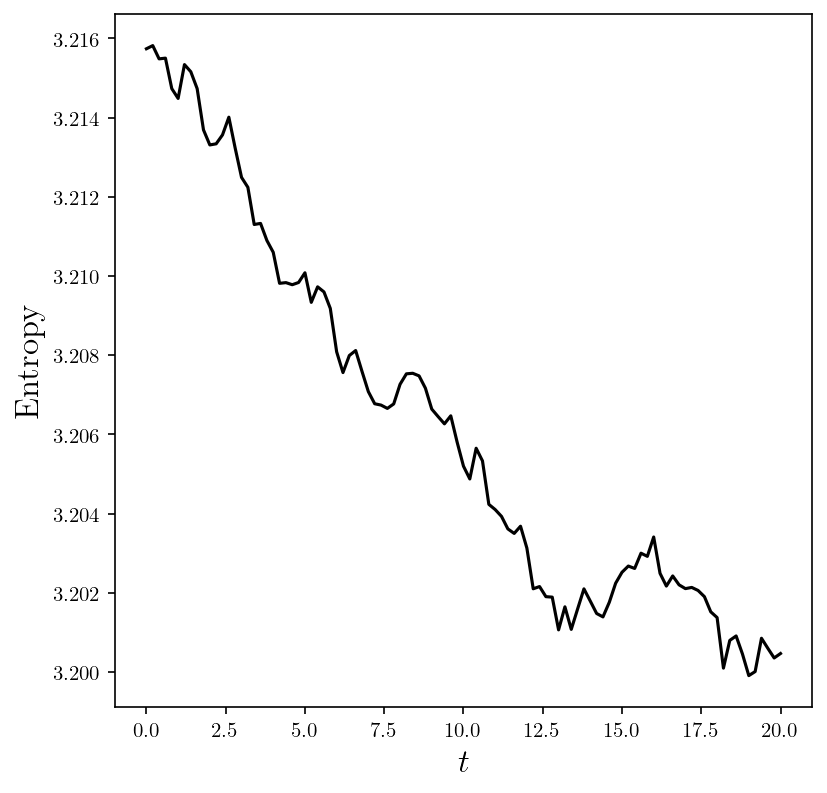

In [ ]:
%matplotlib inline
fig2 = plt.figure(figsize=(6, 6))
ax2 = fig2.add_subplot(111)
ax2.set_xlabel(r'$t$', fontsize=16)
ax2.set_ylabel(r'Entropy', fontsize=16)

ax2.plot(np.linspace(0, COLLISION_PARAMS['n_t'] * COLLISION_PARAMS['dt'], len(entropy_list)), entropy_list, color='black')
plt.show()